In [1]:
!pip install gensim nltk scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 43.9 MB/s eta 0:00:00


In [2]:
import nltk
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from nltk.corpus import brown
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [3]:
nltk.download('brown')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


True

In [4]:
sentences = brown.sents()

data = [[word.lower() for word in sentence] for sentence in sentences]

print("Total Sentences:", len(data))
print(data[0])

Total Sentences: 57340
['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', "atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


In [5]:
model = Word2Vec(
    sentences=data,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [6]:
print("Vocabulary Size:", len(model.wv))

Vocabulary Size: 27805


In [7]:
print("Most similar to 'king':")
print(model.wv.most_similar('king', topn=5))

print("\nMost similar to 'computer':")
print(model.wv.most_similar('computer', topn=5))

Most similar to 'king':
[('payne', 0.9456324577331543), ('annoyance', 0.9447068572044373), ('virgin', 0.9443569183349609), ('queen', 0.9415331482887268), ('mexican', 0.9382080435752869)]

Most similar to 'computer':
[('tool', 0.9477322697639465), ('background', 0.9468702077865601), ('landscape', 0.9391994476318359), ('filtering', 0.93870609998703), ('scheme', 0.938616156578064)]


In [9]:
result = model.wv.most_similar(
    positive=['woman', 'king'],
    negative=['man'],
    topn=5
)

print(result)

[('birthday', 0.930547833442688), ('anna', 0.9244815111160278), ('followers', 0.9233607649803162), ('preaching', 0.9222608804702759), ('defeated', 0.9218449592590332)]


In [10]:
result = model.wv.most_similar(
    positive=['paris', 'italy'],
    negative=['france'],
    topn=5
)

print(result)

[('dawn', 0.936143159866333), ('suite', 0.9294251203536987), ("doaty's", 0.9233705997467041), ('rome', 0.9209597110748291), ('silence', 0.9182438254356384)]


In [11]:
words = [

    'football', 'cricket', 'tennis', 'basketball', 'soccer',
    'player', 'coach', 'stadium', 'match', 'tournament',

    'pizza', 'burger', 'rice', 'pasta', 'coffee',
    'tea', 'bread', 'chicken', 'fruit', 'vegetable',

    'computer', 'internet', 'software', 'hardware', 'keyboard',
    'screen', 'database', 'network', 'python', 'robot',

    'school', 'college', 'teacher', 'student', 'library',

    'river', 'mountain', 'tree', 'forest', 'ocean',

    'car', 'train', 'airplane', 'bus', 'bicycle',

    'music', 'movie', 'book', 'phone', 'camera'
]

In [12]:
word_vectors = []

valid_words = []

for word in words:
    if word in model.wv:
        word_vectors.append(model.wv[word])
        valid_words.append(word)

print("Valid words:", len(valid_words))

Valid words: 44


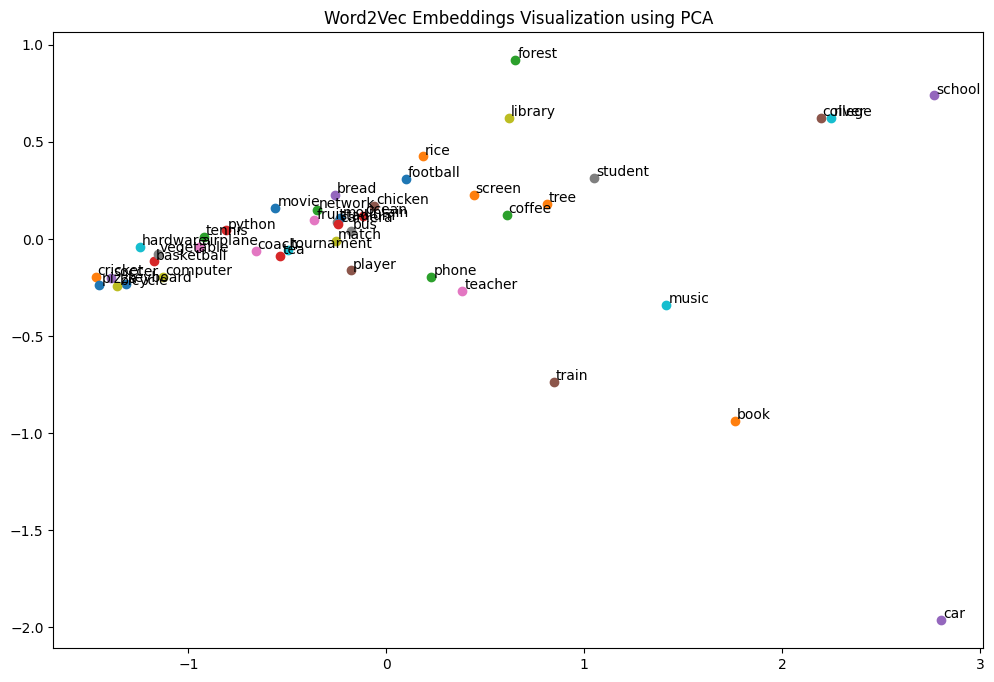

In [13]:
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(12,8))

for i, word in enumerate(valid_words):
    plt.scatter(result[i,0], result[i,1])
    plt.text(result[i,0]+0.01, result[i,1]+0.01, word)

plt.title("Word2Vec Embeddings Visualization using PCA")
plt.show()

In [20]:
import plotly.express as px

pca_3d = PCA(n_components=3)
result_3d = pca_3d.fit_transform(word_vectors)

fig = px.scatter_3d(
    result_3d,
    x=0,
    y=1,
    z=2,
    title="Word2Vec Embeddings Visualization using PCA (3D)"
)

for i, word in enumerate(valid_words):
    fig.add_annotation(
        x=result_3d[i,0],
        y=result_3d[i,1],
        text=word,
        showarrow=False,
        xanchor="left",
        yanchor="middle"
    )

fig.show()

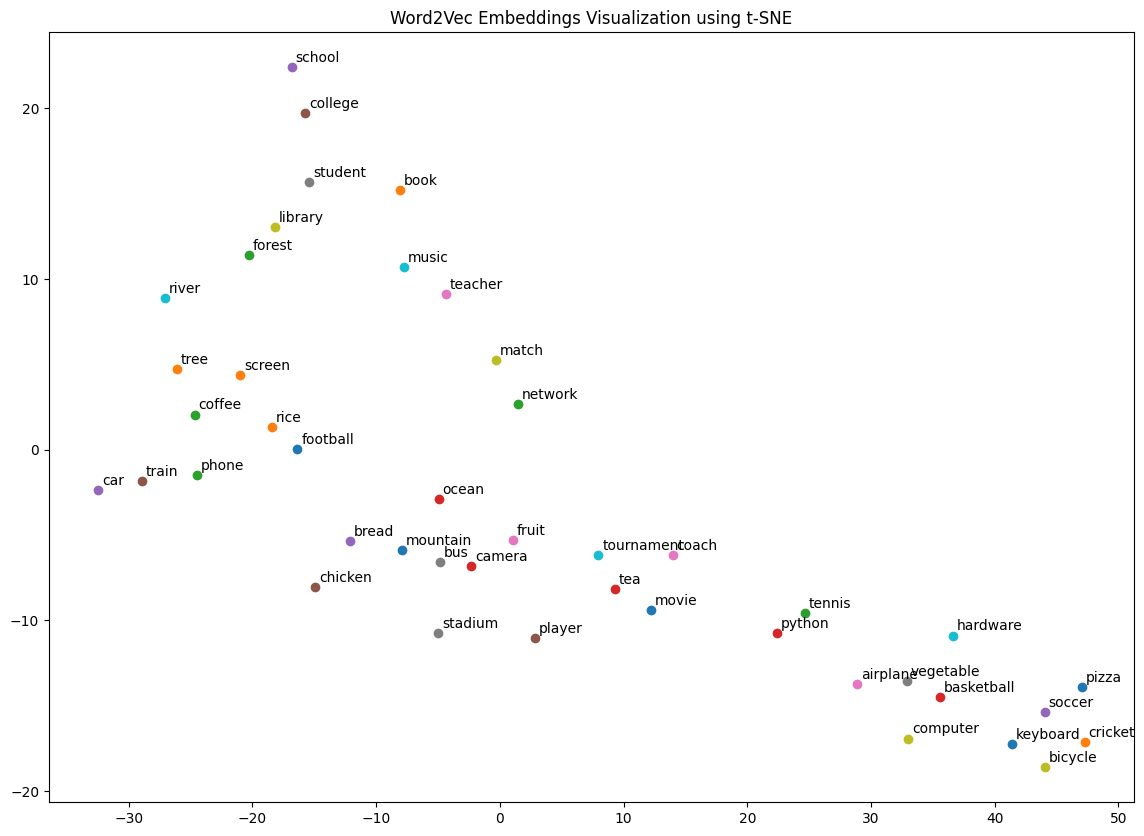

In [16]:
import numpy as np

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)

# Convert list of word vectors to a single NumPy array
word_vectors_np = np.array(word_vectors)
result_tsne = tsne.fit_transform(word_vectors_np)

plt.figure(figsize=(14,10))

for i, word in enumerate(valid_words):
    plt.scatter(result_tsne[i,0], result_tsne[i,1])
    plt.text(result_tsne[i,0]+0.3, result_tsne[i,1]+0.3, word)

plt.title("Word2Vec Embeddings Visualization using t-SNE")
plt.show()